## Parte 0 (ESSENCIAL)

### Setup das bibliotecas

In [1]:
import gzip
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import random
from pathlib import Path
import datetime

### Limitando por data (OPCIONAL)

Definindo qual intervalo de tempo utilizar

In [ ]:
BASE_DIR = Path.cwd()

FILE_PATH = BASE_DIR.parent / "Dados" / "Video_Games.jsonl.gz"

timestamps = []
with gzip.open(FILE_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        review = json.loads(line)
        timestamps.append(review.get("timestamp", 0))

timestamps_segundos = [t / 1000 for t in timestamps]

if timestamps_segundos:
    print("Mais antigo:", datetime.datetime.fromtimestamp(min(timestamps_segundos)))
    print("Mais recente:", datetime.datetime.fromtimestamp(max(timestamps_segundos)))
else:
    print("Nenhum timestamp válido encontrado.")

print("Total de reviews processadas:", len(timestamps))

Mais antigo: 1998-11-17 16:58:49
Mais recente: 2023-09-12 06:02:35.529000
Total de reviews processadas: 4624615


In [ ]:
cortes = [2015, 2017, 2019, 2021]
for ano in cortes:
    ts_corte = datetime.datetime(ano, 1, 1).timestamp() * 1000
    count = sum(1 for t in timestamps if t >= ts_corte)
    print(f"A partir de {ano}: {count} reviews ({count/len(timestamps)*100:.1f}%)")

A partir de 2015: 3572156 reviews (77.2%)
A partir de 2017: 2771514 reviews (59.9%)
A partir de 2019: 2027770 reviews (43.8%)
A partir de 2021: 1058993 reviews (22.9%)


### Calculos do subgrafo

Definindo o grafo como sendo as reviews a partir de 2022 e com compras verificadas

In [ ]:
BASE_DIR = Path.cwd()

FILE_PATH = BASE_DIR.parent / "Dados" / "Video_Games.jsonl.gz"

TIMESTAMP_CORTE = datetime.datetime(2023, 1, 1).timestamp() * 1000

count_2022_verified = 0

with gzip.open(FILE_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        review = json.loads(line)
        ts = review.get("timestamp", 0)
        verified = review.get("verified_purchase", False)
        
        if ts >= TIMESTAMP_CORTE and verified:
            count_2022_verified += 1

print(f"reviews 2022 + verified: {count_2022_verified}")

reviews 2022 + verified: 515612


Definindo o grafo

In [3]:
G_raw = nx.MultiGraph()

with gzip.open(FILE_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        review = json.loads(line)
        if review.get("timestamp", 0) < TIMESTAMP_CORTE:
            continue
        if not review.get("verified_purchase", False):
            continue
        user = "u_" + review["user_id"]
        product = "p_" + review["asin"]
        G_raw.add_node(user, node_type="user")
        G_raw.add_node(product, node_type="product")
        G_raw.add_edge(user, product, timestamp=review.get("timestamp", 0))

print(f"Nós: {G_raw.number_of_nodes()}")
print(f"Arestas (com duplicatas): {G_raw.number_of_edges()}")

Nós: 465565
Arestas (com duplicatas): 515612


Simplificando

In [4]:
G = nx.Graph()

for u, v, data in G_raw.edges(data=True):
    if not G.has_edge(u, v):
        G.add_edge(u, v)

for node, data in G_raw.nodes(data=True):
    if node in G:
        G.nodes[node]["node_type"] = data["node_type"]

G.remove_edges_from(nx.selfloop_edges(G))

print(f"Após simplificação:")
print(f"Nós: {G.number_of_nodes()}")
print(f"Arestas: {G.number_of_edges()}")

components = list(nx.connected_components(G))
print(f"\nComponentes no grafo original: {len(components)}")

largest_cc = max(components, key=len)
G_lcc = G.subgraph(largest_cc).copy()

print(f"\nApós extrair o maior componente conexo:")
print(f"Nós: {G_lcc.number_of_nodes()}")
print(f"Arestas: {G_lcc.number_of_edges()}")

Após simplificação:
Nós: 465565
Arestas: 508715

Componentes no grafo original: 22720

Após extrair o maior componente conexo:
Nós: 400637
Arestas: 466498


### Plotagem do grafico em imagens (OPCIONAL)

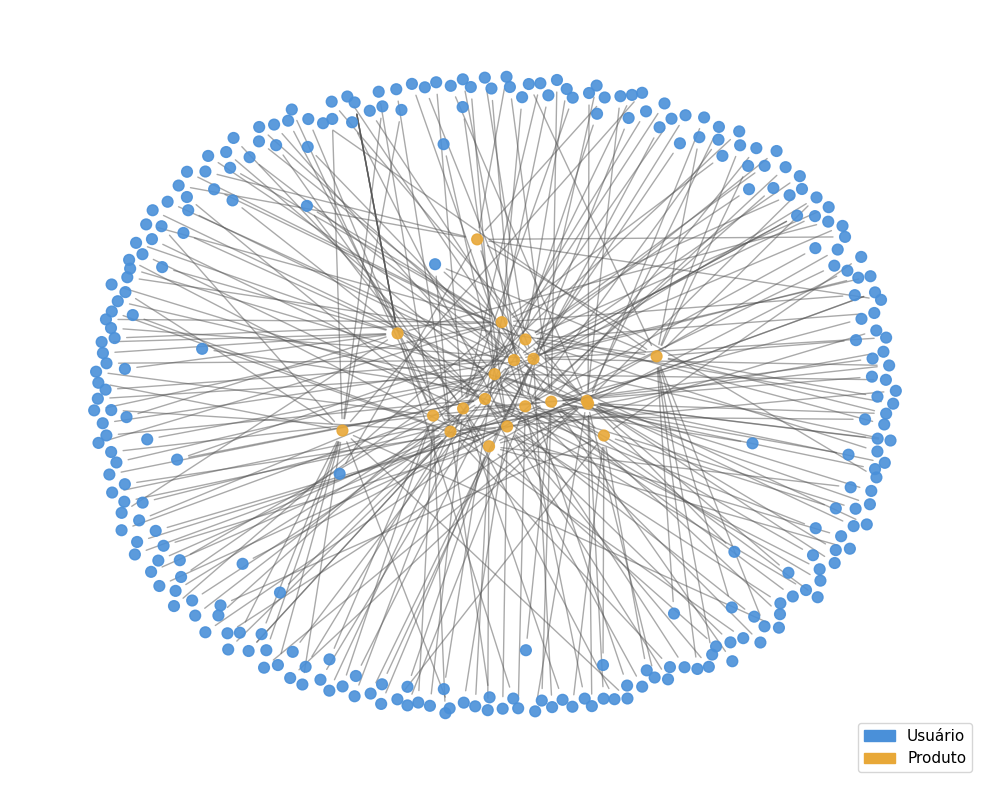

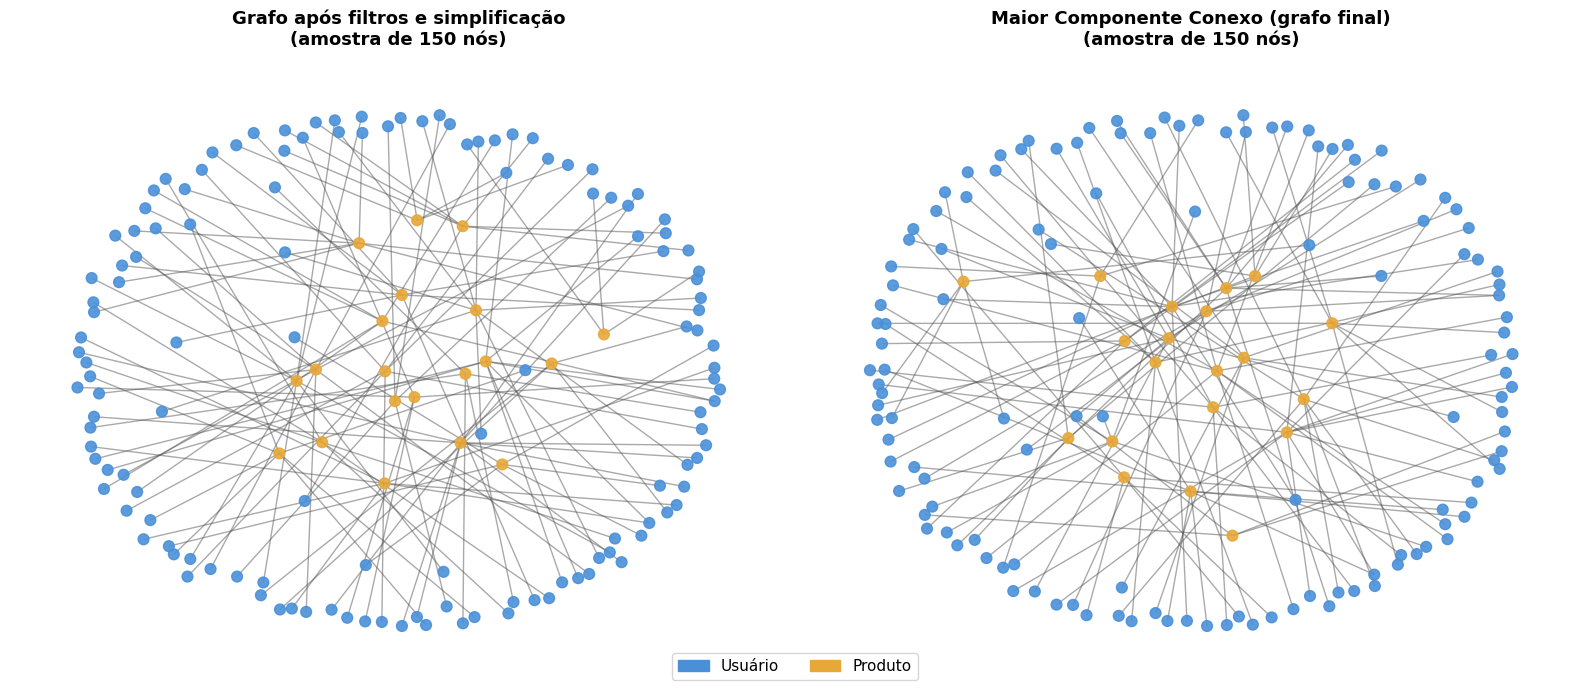

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

def sample_connected_subgraph(G_source, n_nodes=300, seed=42):
    random.seed(seed)
    
    product_nodes = sorted(
        [(n, d) for n, d in G_source.degree() if n.startswith("p_")],
        key=lambda x: x[1], reverse=True
    )
    
    top_products = [p for p, _ in product_nodes[:20]]
    
    users = []
    for product in top_products:
        neighbors = list(G_source.neighbors(product))
        random.shuffle(neighbors)
        users.extend(neighbors[:25])
    
    users = list(set(users))
    n_users = min(len(users), n_nodes - len(top_products))
    selected = top_products + users[:n_users]
    
    return G_source.subgraph(selected)

def plot_subgraph(G_source, title, ax, seed=42, n_nodes=int):
    H = sample_connected_subgraph(G_source, n_nodes, seed=seed)
    node_colors = [
        "#4A90D9" if G_source.nodes[n].get("node_type") == "user" else "#E8A838"
        for n in H.nodes()
    ]
    pos = nx.spring_layout(H, seed=seed, k=1.2, iterations=80)
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.5, width=1.0, edge_color="#555555")
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors, node_size=60, alpha=0.9)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.axis("off")

fig2, ax2 = plt.subplots(figsize=(10, 8))
plot_subgraph(G_raw, "", ax2, n_nodes=300)
user_patch = mpatches.Patch(color="#4A90D9", label="Usuário")
product_patch = mpatches.Patch(color="#E8A838", label="Produto")
ax2.legend(handles=[user_patch, product_patch], loc="lower right", fontsize=11)
plt.tight_layout()
plt.savefig("teaser_figure.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_subgraph(G, "Grafo após filtros e simplificação\n(amostra de 150 nós)", axes[0], n_nodes=150)
plot_subgraph(G_lcc, "Maior Componente Conexo (grafo final)\n(amostra de 150 nós)", axes[1], n_nodes=150)

user_patch = mpatches.Patch(color="#4A90D9", label="Usuário")
product_patch = mpatches.Patch(color="#E8A838", label="Produto")
fig.legend(handles=[user_patch, product_patch], loc="lower center",
           ncol=2, fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout()
plt.savefig("grafo_visualizacao.png", dpi=150, bbox_inches="tight")
plt.show()

## Parte 1

Metricas basicas

In [50]:
import numpy as np

n = G_lcc.number_of_nodes()
m = G_lcc.number_of_edges()
degree_values = [d for _, d in G_lcc.degree()]

print(f"Número de vértices: {n}")
print(f"Número de arestas: {m}")
print(f"Grau mínimo: {min(degree_values)}")
print(f"Grau máximo: {max(degree_values)}")
print(f"Grau médio: {np.mean(degree_values):.4f}")
print(f"Densidade: {nx.density(G_lcc):.8f}")
print(f"Número de componentes conexos (grafo pré-LCC): {nx.number_connected_components(G)}")
print(f"Tamanho da maior componente: {n}")
print(f"Tamanho das demais componentes: min={min(len(c) for c in nx.connected_components(G) if len(c) < n)}, "
      f"max={max(len(c) for c in nx.connected_components(G) if len(c) < n)}")

Número de vértices: 400637
Número de arestas: 466498
Grau mínimo: 1
Grau máximo: 2955
Grau médio: 2.3288
Densidade: 0.00000581
Número de componentes conexos (grafo pré-LCC): 22720
Tamanho da maior componente: 400637
Tamanho das demais componentes: min=2, max=100


Distribuicao de graus

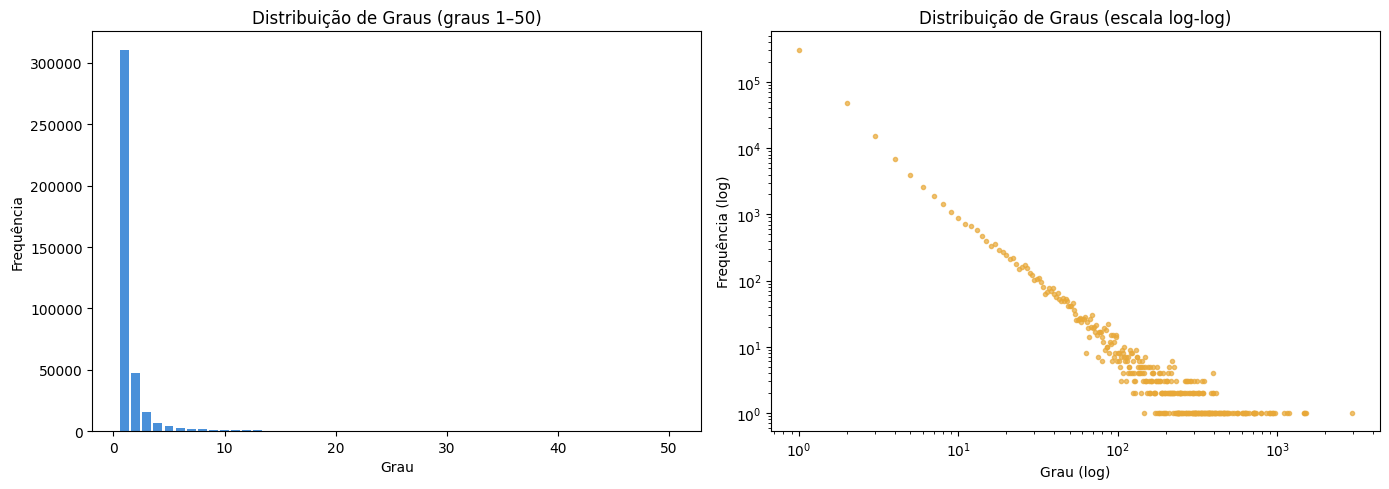

Nós com grau 1: 310275
Nós com grau 2: 47635
Nós com grau >= 100: 670


In [38]:
from collections import Counter

degree_count = Counter(degree_values)
graus = sorted(degree_count.keys())
frequencias = [degree_count[g] for g in graus]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(graus[:50], frequencias[:50], color="#4A90D9", edgecolor="none")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.title("Distribuição de Graus (graus 1–50)")

plt.subplot(1, 2, 2)
plt.loglog(graus, frequencias, "o", markersize=3, color="#E8A838", alpha=0.7)
plt.xlabel("Grau (log)")
plt.ylabel("Frequência (log)")
plt.title("Distribuição de Graus (escala log-log)")

plt.tight_layout()
plt.savefig("distribuicao_graus.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Nós com grau 1: {degree_count[1]}")
print(f"Nós com grau 2: {degree_count[2]}")
print(f"Nós com grau >= 100: {sum(v for k,v in degree_count.items() if k >= 100)}")

Diametro, raio e comprimento medio (por amostragem) (apox. 4 min)


In [49]:
from collections import deque
import random

def bfs_distances(G, source):
    distances = {source: 0}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        for neighbor in G.neighbors(node):
            if neighbor not in distances:
                distances[neighbor] = distances[node] + 1
                queue.append(neighbor)
    return distances

random.seed(42)
sample_nodes = random.sample(list(G_lcc.nodes()), 500)
print(f"Processando 500 nós")

eccentricities = []
all_distances = []

for i, node in enumerate(sample_nodes):
    dist = bfs_distances(G_lcc, node)
    ecc = max(dist.values())
    eccentricities.append(ecc)
    all_distances.extend(dist.values())
    if i % 10 == 0:
        print(f"  {i}", end=" ")

print()        
print(f"\nDiâmetro aproximado: {max(eccentricities)}")
print(f"Raio aproximado: {min(eccentricities)}")
print(f"Comprimento médio dos caminhos: {np.mean([d for d in all_distances if d > 0]):.4f}")

Processando 500 nós
  0   10   20   30   40   50   60   70   80   90   100   110   120   130   140   150   160   170   180   190   200   210   220   230   240   250   260   270   280   290   300   310   320   330   340   350   360   370   380   390   400   410   420   430   440   450   460   470   480   490 

Diâmetro aproximado: 21
Raio aproximado: 14
Comprimento médio dos caminhos: 7.5893


Coeficiente de clusterizacao e triangulos

In [51]:
avg_clustering = nx.average_clustering(G_lcc)
triangles = sum(nx.triangles(G_lcc).values()) // 3

print(f"Coeficiente de clusterização médio: {avg_clustering:.6f}")
print(f"Número de triângulos: {triangles}")

Coeficiente de clusterização médio: 0.000000
Número de triângulos: 0


## Parte 2

BFS

In [69]:
import time
from collections import deque

def bfs(G, source):
    visited = {source: 0}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                visited[neighbor] = visited[node] + 1
                queue.append(neighbor)
    return visited

source = random.choice(list(G_lcc.nodes()))

tempos_bfs = []
for _ in range(30):
    inicio = time.perf_counter()
    resultado_bfs = bfs(G_lcc, source)
    tempos_bfs.append(time.perf_counter() - inicio)

media_bfs = np.mean(tempos_bfs)
std_bfs = np.std(tempos_bfs, ddof=1)
z = 1.96
ic_bfs = z * (std_bfs / np.sqrt(len(tempos_bfs)))

print(f"BFS (nós visitados): {len(resultado_bfs)}")
print(f"Média: {media_bfs:.4f}s")
print(f"Desvio padrão: {std_bfs:.4f}s")
print(f"IC 95%: [{media_bfs - ic_bfs:.4f}, {media_bfs + ic_bfs:.4f}]")

BFS (nós visitados): 400637
Média: 0.5471s
Desvio padrão: 0.2056s
IC 95%: [0.4735, 0.6206]


DFS

In [70]:
def dfs(G, source):
    visited = {}
    stack = [(source, 0)]
    while stack:
        node, depth = stack.pop()
        if node not in visited:
            visited[node] = depth
            for neighbor in G.neighbors(node):
                if neighbor not in visited:
                    stack.append((neighbor, depth + 1))
    return visited

tempos_dfs = []
for _ in range(30):
    inicio = time.perf_counter()
    resultado_dfs = dfs(G_lcc, source)
    tempos_dfs.append(time.perf_counter() - inicio)

media_dfs = np.mean(tempos_dfs)
std_dfs = np.std(tempos_dfs, ddof=1)
ic_dfs = z * (std_dfs / np.sqrt(len(tempos_dfs)))

print(f"DFS (nós visitados): {len(resultado_dfs)}")
print(f"Média: {media_dfs:.4f}s")
print(f"Desvio padrão: {std_dfs:.4f}s")
print(f"IC 95%: [{media_dfs - ic_dfs:.4f}, {media_dfs + ic_dfs:.4f}]")

DFS (nós visitados): 400637
Média: 0.7136s
Desvio padrão: 0.2400s
IC 95%: [0.6277, 0.7994]


Eulerianidade

In [71]:
def verificar_eulerianidade(G):
    nos_grau_impar = [n for n, d in G.degree() if d % 2 != 0]
    n_impar = len(nos_grau_impar)
    
    if n_impar == 0:
        return "Circuito Euleriano", n_impar
    elif n_impar == 2:
        return "Caminho Euleriano", n_impar
    else:
        return "Não Euleriano", n_impar

tempos_euler = []
for _ in range(30):
    inicio = time.perf_counter()
    resultado_euler, n_impar = verificar_eulerianidade(G_lcc)
    tempos_euler.append(time.perf_counter() - inicio)

media_euler = np.mean(tempos_euler)
std_euler = np.std(tempos_euler, ddof=1)
ic_euler = z * (std_euler / np.sqrt(len(tempos_euler)))

print(f"Resultado: {resultado_euler}")
print(f"Nós com grau ímpar: {n_impar}")
print(f"Média: {media_euler:.4f}s")
print(f"Desvio padrão: {std_euler:.4f}s")
print(f"IC 95%: [{media_euler - ic_euler:.4f}, {media_euler + ic_euler:.4f}]")

Resultado: Não Euleriano
Nós com grau ímpar: 336950
Média: 0.2260s
Desvio padrão: 0.0393s
IC 95%: [0.2119, 0.2401]


Dijkstra

In [72]:
import heapq

random.seed(42)
for u, v in G_lcc.edges():
    G_lcc[u][v]["weight"] = random.randint(1, 10)

def dijkstra(G, source):
    dist = {source: 0}
    heap = [(0, source)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > dist.get(u, float("inf")):
            continue
        for v in G.neighbors(u):
            w = G[u][v]["weight"]
            nd = d + w
            if nd < dist.get(v, float("inf")):
                dist[v] = nd
                heapq.heappush(heap, (nd, v))
    return dist

tempos_dijkstra = []
for _ in range(30):
    inicio = time.perf_counter()
    resultado_dijkstra = dijkstra(G_lcc, source)
    tempos_dijkstra.append(time.perf_counter() - inicio)

media_dijkstra = np.mean(tempos_dijkstra)
std_dijkstra = np.std(tempos_dijkstra, ddof=1)
ic_dijkstra = z * (std_dijkstra / np.sqrt(len(tempos_dijkstra)))

print(f"Dijkstra (nós alcançados): {len(resultado_dijkstra)}")
print(f"Média: {media_dijkstra:.4f}s")
print(f"Desvio padrão: {std_dijkstra:.4f}s")
print(f"IC 95%: [{media_dijkstra - ic_dijkstra:.4f}, {media_dijkstra + ic_dijkstra:.4f}]")

KeyboardInterrupt: 

Bellman-Ford e Floyd-Warshall

Para esses dois algoritmos, o tamanho atual do grafo deixaria inviavel a execução em um tempo ideal, por isso, con base no grafo final (maior componente conexo) pego um subgrafo de 300 nós para utilizar nesses algoritmos.

Subgrafo de 300 nós

In [ ]:
random.seed(42)
start_node = random.choice(list(G_lcc.nodes()))
nos_sub = list(bfs(G_lcc, start_node).keys())[:300]
G_sub = G_lcc.subgraph(nos_sub).copy()

for u, v in G_sub.edges():
    G_sub[u][v]["weight"] = random.randint(1, 10)

print(f"Subgrafo (nós): {G_sub.number_of_nodes()}")
print(f"Subgrafo (arestas): {G_sub.number_of_edges()}")

Subgrafo (nós): 300
Subgrafo (arestas): 299


Bellman-Ford

In [ ]:
def bellman_ford(G, source):
    dist = {n: float("inf") for n in G.nodes()}
    dist[source] = 0
    nodes = list(G.nodes())
    edges = list(G.edges(data=True))
    
    for _ in range(len(nodes) - 1):
        for u, v, data in edges:
            w = data["weight"]
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
            if dist[v] + w < dist[u]:
                dist[u] = dist[v] + w
    return dist

source_sub = nos_sub[0]

tempos_bf = []
for _ in range(30):
    inicio = time.perf_counter()
    resultado_bf = bellman_ford(G_sub, source_sub)
    tempos_bf.append(time.perf_counter() - inicio)

media_bf = np.mean(tempos_bf)
std_bf = np.std(tempos_bf, ddof=1)
ic_bf = z * (std_bf / np.sqrt(len(tempos_bf)))

print(f"Bellman-Ford (nós alcançados): {sum(1 for d in resultado_bf.values() if d < float('inf'))}")
print(f"Média: {media_bf:.4f}s")
print(f"Desvio padrão: {std_bf:.4f}s")
print(f"IC 95%: [{media_bf - ic_bf:.4f}, {media_bf + ic_bf:.4f}]")

Bellman-Ford (nós alcançados): 300
Média: 0.0206s
Desvio padrão: 0.0084s
IC 95%: [0.0176, 0.0236]


Floyd-Warshall

In [ ]:
def floyd_warshall(G):
    nodes = list(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)
    
    dist = [[float("inf")] * n for _ in range(n)]
    for i in range(n):
        dist[i][i] = 0
    for u, v, data in G.edges(data=True):
        i, j = idx[u], idx[v]
        dist[i][j] = data["weight"]
        dist[j][i] = data["weight"]
    
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
    return dist

tempos_fw = []
for _ in range(10):
    inicio = time.perf_counter()
    resultado_fw = floyd_warshall(G_sub)
    tempos_fw.append(time.perf_counter() - inicio)

media_fw = np.mean(tempos_fw)
std_fw = np.std(tempos_fw, ddof=1)
t = 2.262  # t-Student 95%, n=10, gl=9
ic_fw = t * (std_fw / np.sqrt(len(tempos_fw)))

print(f"Floyd-Warshall ({len(resultado_fw)}x{len(resultado_fw[0])} matriz)")
print(f"Média: {media_fw:.4f}s")
print(f"Desvio padrão: {std_fw:.4f}s")
print(f"IC 95% (t-Student): [{media_fw - ic_fw:.4f}, {media_fw + ic_fw:.4f}]")

Floyd-Warshall (300x300 matriz)
Média: 2.0113s
Desvio padrão: 0.4078s
IC 95% (t-Student): [1.7196, 2.3030]


Tarjan

Já para esse algoritmo, como o grafo é não-direcionado, vou convertê-lo para dirigido, adicionando ambas as direções

In [ ]:
def tarjan_scc_iterativo(G):
    G_dir = nx.DiGraph(G)
    
    index_counter = [0]
    stack = []
    lowlink = {}
    index = {}
    on_stack = {}
    sccs = []

    for source in G_dir.nodes():
        if source in index:
            continue
        
        work_stack = [(source, iter(G_dir.successors(source)))]
        index[source] = lowlink[source] = index_counter[0]
        index_counter[0] += 1
        stack.append(source)
        on_stack[source] = True

        while work_stack:
            v, neighbors = work_stack[-1]
            try:
                w = next(neighbors)
                if w not in index:
                    index[w] = lowlink[w] = index_counter[0]
                    index_counter[0] += 1
                    stack.append(w)
                    on_stack[w] = True
                    work_stack.append((w, iter(G_dir.successors(w))))
                elif on_stack[w]:
                    lowlink[v] = min(lowlink[v], index[w])
            except StopIteration:
                work_stack.pop()
                if work_stack:
                    parent = work_stack[-1][0]
                    lowlink[parent] = min(lowlink[parent], lowlink[v])
                if lowlink[v] == index[v]:
                    scc = []
                    while True:
                        w = stack.pop()
                        on_stack[w] = False
                        scc.append(w)
                        if w == v:
                            break
                    sccs.append(scc)
    return sccs

tempos_tarjan = []
for _ in range(10):
    inicio = time.perf_counter()
    sccs = tarjan_scc_iterativo(G_lcc)
    tempos_tarjan.append(time.perf_counter() - inicio)

media_tarjan = np.mean(tempos_tarjan)
std_tarjan = np.std(tempos_tarjan, ddof=1)
t = 2.262
ic_tarjan = t * (std_tarjan / np.sqrt(len(tempos_tarjan)))

print(f"Componentes Fortemente Conexos: {len(sccs)}")
print(f"Tamanho da maior SCC: {max(len(s) for s in sccs)}")
print(f"Média: {media_tarjan:.4f}s")
print(f"Desvio padrão: {std_tarjan:.4f}s")
print(f"IC 95% (t-Student): [{media_tarjan - ic_tarjan:.4f}, {media_tarjan + ic_tarjan:.4f}]")

Componentes Fortemente Conexos: 1
Tamanho da maior SCC: 400637
Média: 6.8161s
Desvio padrão: 1.9706s
IC 95% (t-Student): [5.4065, 8.2257]


Prim e Kruskal

In [ ]:
def prim(G, source):
    mst_edges = []
    visitados = {source}
    heap = [(data["weight"], source, v) 
            for v, data in G[source].items()]
    heapq.heapify(heap)
    
    while heap:
        peso, u, v = heapq.heappop(heap)
        if v not in visitados:
            visitados.add(v)
            mst_edges.append((u, v, peso))
            for w, data in G[v].items():
                if w not in visitados:
                    heapq.heappush(heap, (data["weight"], v, w))
    return mst_edges

def kruskal(G):
    parent = {n: n for n in G.nodes()}
    rank = {n: 0 for n in G.nodes()}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx == ry:
            return False
        if rank[rx] < rank[ry]:
            rx, ry = ry, rx
        parent[ry] = rx
        if rank[rx] == rank[ry]:
            rank[rx] += 1
        return True

    mst_edges = []
    for u, v, data in sorted(G.edges(data=True), key=lambda x: x[2]["weight"]):
        if union(u, v):
            mst_edges.append((u, v, data["weight"]))
    return mst_edges

tempos_prim, tempos_kruskal = [], []

for _ in range(30):
    inicio = time.perf_counter()
    mst_prim = prim(G_lcc, source)
    tempos_prim.append(time.perf_counter() - inicio)

for _ in range(30):
    inicio = time.perf_counter()
    mst_kruskal = kruskal(G_lcc)
    tempos_kruskal.append(time.perf_counter() - inicio)

for nome, tempos in [("Prim", tempos_prim), ("Kruskal", tempos_kruskal)]:
    media = np.mean(tempos)
    std = np.std(tempos, ddof=1)
    ic = z * (std / np.sqrt(len(tempos)))
    print(f"{nome}:")
    print(f"  Arestas na MST: {len(mst_prim) if nome == 'Prim' else len(mst_kruskal)}")
    print(f"  Média: {media:.4f}s | Desvio: {std:.4f}s | IC 95%: [{media-ic:.4f}, {media+ic:.4f}]")

Prim:
  Arestas na MST: 400636
  Média: 2.2226s | Desvio: 0.4594s | IC 95%: [2.0582, 2.3870]
Kruskal:
  Arestas na MST: 400636
  Média: 2.3729s | Desvio: 0.4095s | IC 95%: [2.2264, 2.5195]


## Parte 3

Small-World

In [75]:
import math

N = G_lcc.number_of_nodes()
k_medio = np.mean([d for _, d in G_lcc.degree()])
L_obs = 7.5893
C_obs = 0.0

L_rand = math.log(N) / math.log(k_medio)
C_rand = k_medio / N

print(f"Small-World")
print(f"N = {N}, k_médio = {k_medio:.4f}")
print(f"\nComprimento médio observado (L):      {L_obs:.4f}")
print(f"Comprimento médio aleatório (L_rand): {L_rand:.4f}")
print(f"Razão L/L_rand:                       {L_obs/L_rand:.4f}")
print(f"\nClusterização observada (C):      {C_obs:.6f}")
print(f"Clusterização aleatória (C_rand): {C_rand:.6f}")

if C_rand > 0:
    sigma = (C_obs / C_rand) / (L_obs / L_rand)
    print(f"\nCoeficiente small-world (σ): {sigma:.4f}")
    print(f"Small-world: {'Sim (σ > 1)' if sigma > 1 else 'Não (σ ≤ 1)'}")
else:
    print(f"\nσ indefinido — C_rand ≈ 0")

Small-World
N = 400637, k_médio = 2.3288

Comprimento médio observado (L):      7.5893
Comprimento médio aleatório (L_rand): 15.2610
Razão L/L_rand:                       0.4973

Clusterização observada (C):      0.000000
Clusterização aleatória (C_rand): 0.000006

Coeficiente small-world (σ): 0.0000
Small-world: Não (σ ≤ 1)


Power Law

Expoente γ estimado: 1.6495
Constante C: 0.051502


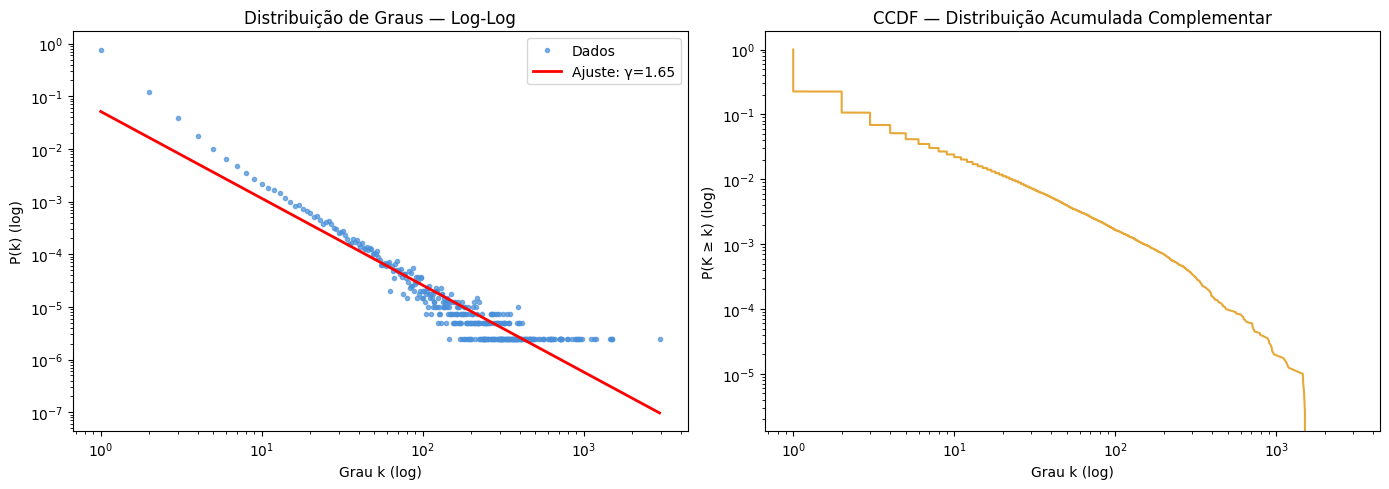

In [ ]:
from collections import Counter
import numpy as np

degree_count = Counter(degree_values)
graus = np.array(sorted(degree_count.keys()))
frequencias = np.array([degree_count[g] for g in graus])
prob = frequencias / frequencias.sum()

mask = graus >= 1
log_k = np.log(graus[mask])
log_p = np.log(prob[mask])

coeffs = np.polyfit(log_k, log_p, 1)
gamma = -coeffs[0]
C_fit = np.exp(coeffs[1])
print(f"Expoente γ estimado: {gamma:.4f}")
print(f"Constante C: {C_fit:.6f}")

graus_sorted = np.sort(list(degree_count.elements()))
ccdf = 1 - np.arange(1, len(graus_sorted)+1) / len(graus_sorted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(graus[mask], prob[mask], "o", markersize=3,
               color="#4A90D9", alpha=0.7, label="Dados")
k_fit = np.linspace(graus[mask].min(), graus[mask].max(), 200)
axes[0].loglog(k_fit, C_fit * k_fit**(-gamma), "r-",
               linewidth=2, label=f"Ajuste: γ={gamma:.2f}")
axes[0].set_xlabel("Grau k (log)")
axes[0].set_ylabel("P(k) (log)")
axes[0].set_title("Distribuição de Graus — Log-Log")
axes[0].legend()

axes[1].loglog(graus_sorted, ccdf, color="#E8A838", linewidth=1.5)
axes[1].set_xlabel("Grau k (log)")
axes[1].set_ylabel("P(K ≥ k) (log)")
axes[1].set_title("CCDF — Distribuição Acumulada Complementar")

plt.tight_layout()
plt.savefig("power_law.png", dpi=150, bbox_inches="tight")
plt.show()

Robustez (aprox. 2 min)

In [78]:
r = int(0.05 * G_lcc.number_of_nodes())
print(f"Nós a remover: {r}")

def metricas_robustez(G):
    n = G.number_of_nodes()
    if n == 0:
        return 0, 0, 0
    comps = list(nx.connected_components(G))
    lcc_size = max(len(c) for c in comps) / G_lcc.number_of_nodes()
    n_comps = len(comps)
    isolados = sum(1 for c in comps if len(c) == 1) / G_lcc.number_of_nodes()
    return lcc_size, n_comps, isolados

resultados_rand = []
for i in range(30):
    nos_remover = random.sample(list(G_lcc.nodes()), r)
    G_temp = G_lcc.copy()
    G_temp.remove_nodes_from(nos_remover)
    resultados_rand.append(metricas_robustez(G_temp))
    if i % 5 == 0:
        print(f"  Aleatória: {i}/30")

nos_por_grau = sorted(G_lcc.degree(), key=lambda x: x[1], reverse=True)
nos_centrais = [n for n, _ in nos_por_grau[:r]]
G_temp_cent = G_lcc.copy()
G_temp_cent.remove_nodes_from(nos_centrais)
resultado_cent = metricas_robustez(G_temp_cent)

lcc_rand = [r[0] for r in resultados_rand]
comp_rand = [r[1] for r in resultados_rand]
isol_rand = [r[2] for r in resultados_rand]

print(f"\nRemoção Aleatória (30 repetições)")
print()
print(f"LCC média: {np.mean(lcc_rand):.4f} ± {np.std(lcc_rand):.4f}")
print(f"Componentes média: {np.mean(comp_rand):.1f} ± {np.std(comp_rand):.1f}")
print(f"Isolados média: {np.mean(isol_rand):.4f} ± {np.std(isol_rand):.4f}")
print()

print(f"\nRemoção Direcionada (grau)")
print()
print(f"LCC: {resultado_cent[0]:.4f}")
print(f"Componentes: {resultado_cent[1]}")
print(f"Isolados: {resultado_cent[2]:.4f}")

Nós a remover: 20031
  Aleatória: 0/30
  Aleatória: 5/30
  Aleatória: 10/30
  Aleatória: 15/30
  Aleatória: 20/30
  Aleatória: 25/30

Remoção Aleatória (30 repetições)

LCC média: 0.9041 ± 0.0033
Componentes média: 15540.1 ± 1241.4
Isolados média: 0.0366 ± 0.0030


Remoção Direcionada (grau)

LCC: 0.0001
Componentes: 342679
Isolados: 0.8171


Boxplot

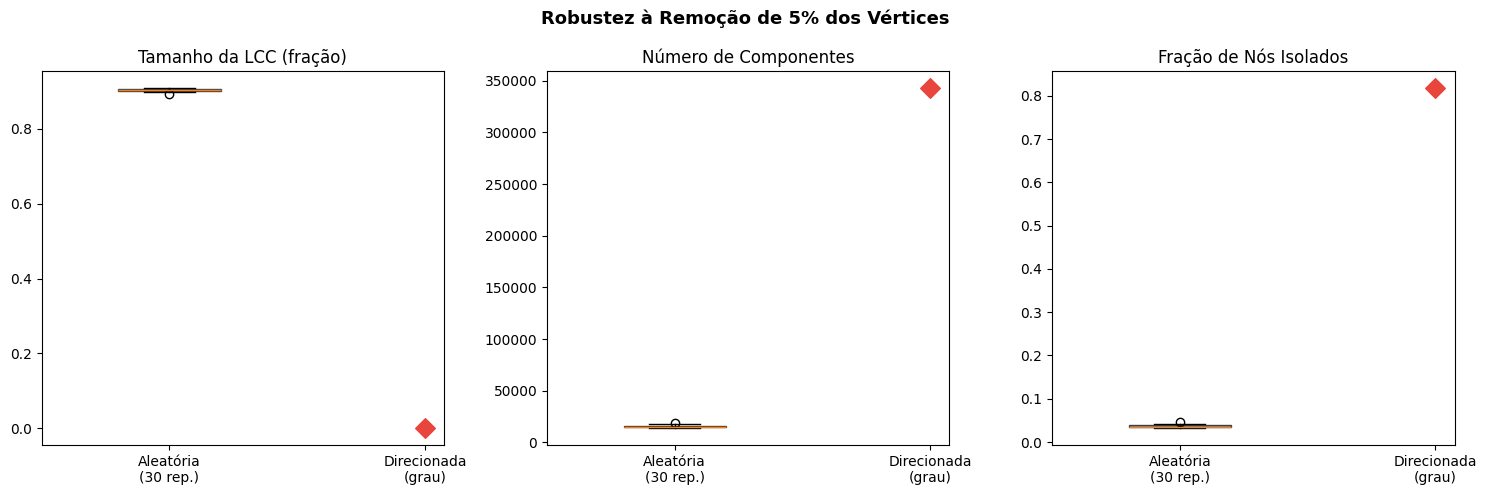

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = [
    (lcc_rand, resultado_cent[0], "Tamanho da LCC (fração)", axes[0]),
    (comp_rand, resultado_cent[1], "Número de Componentes", axes[1]),
    (isol_rand, resultado_cent[2], "Fração de Nós Isolados", axes[2]),
]

for rand_vals, cent_val, titulo, ax in metricas:
    ax.boxplot(rand_vals, positions=[1], widths=0.4,
               patch_artist=True, boxprops=dict(facecolor="#4A90D9", alpha=0.7))
    ax.scatter([2], [cent_val], color="#E8453C", s=100, zorder=5, marker="D")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Aleatória\n(30 rep.)", "Direcionada\n(grau)"])
    ax.set_title(titulo)

plt.suptitle("Robustez à Remoção de 5% dos Vértices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("robustez.png", dpi=150, bbox_inches="tight")
plt.show()